3) Convolutional neural network (CNN) (Any One from the following)
• Use any dataset of plant disease and design a plant disease detection system using
CNN.
• Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into
categories

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi'] = 250
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

In [3]:
train_df
#28*28=784 pixels 

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train_df['label'].nunique()

10

In [5]:
label_names = ['t_shirt','trouser','pullover','dress','coat','sandal','shirt','sneaker','bag','ankle_boot']


In [6]:
xtrain = train_df.iloc[:,1:].values #Take all rows,start from column index 1 till end
ytrain = train_df.iloc[:,0].values # Take first column

xtest = test_df.iloc[:,1:].values
ytest = test_df.iloc[:,0].values

In [7]:
xtrain = xtrain/255.0
xtest = xtest/255.0
# Normalize pixel values from range 0-255 to 0-1

In [8]:
xtrain = xtrain.reshape(-1,28,28,1)
xtest = xtest.reshape(-1,28,28,1)
print("Train shape: ",xtrain.shape)
print("Test shape : ",xtest.shape)
# Reshaping flattened image data into 28x28 image format
# CNN expects 4D input: (samples, height, width, channels)

Train shape:  (60000, 28, 28, 1)
Test shape :  (10000, 28, 28, 1)


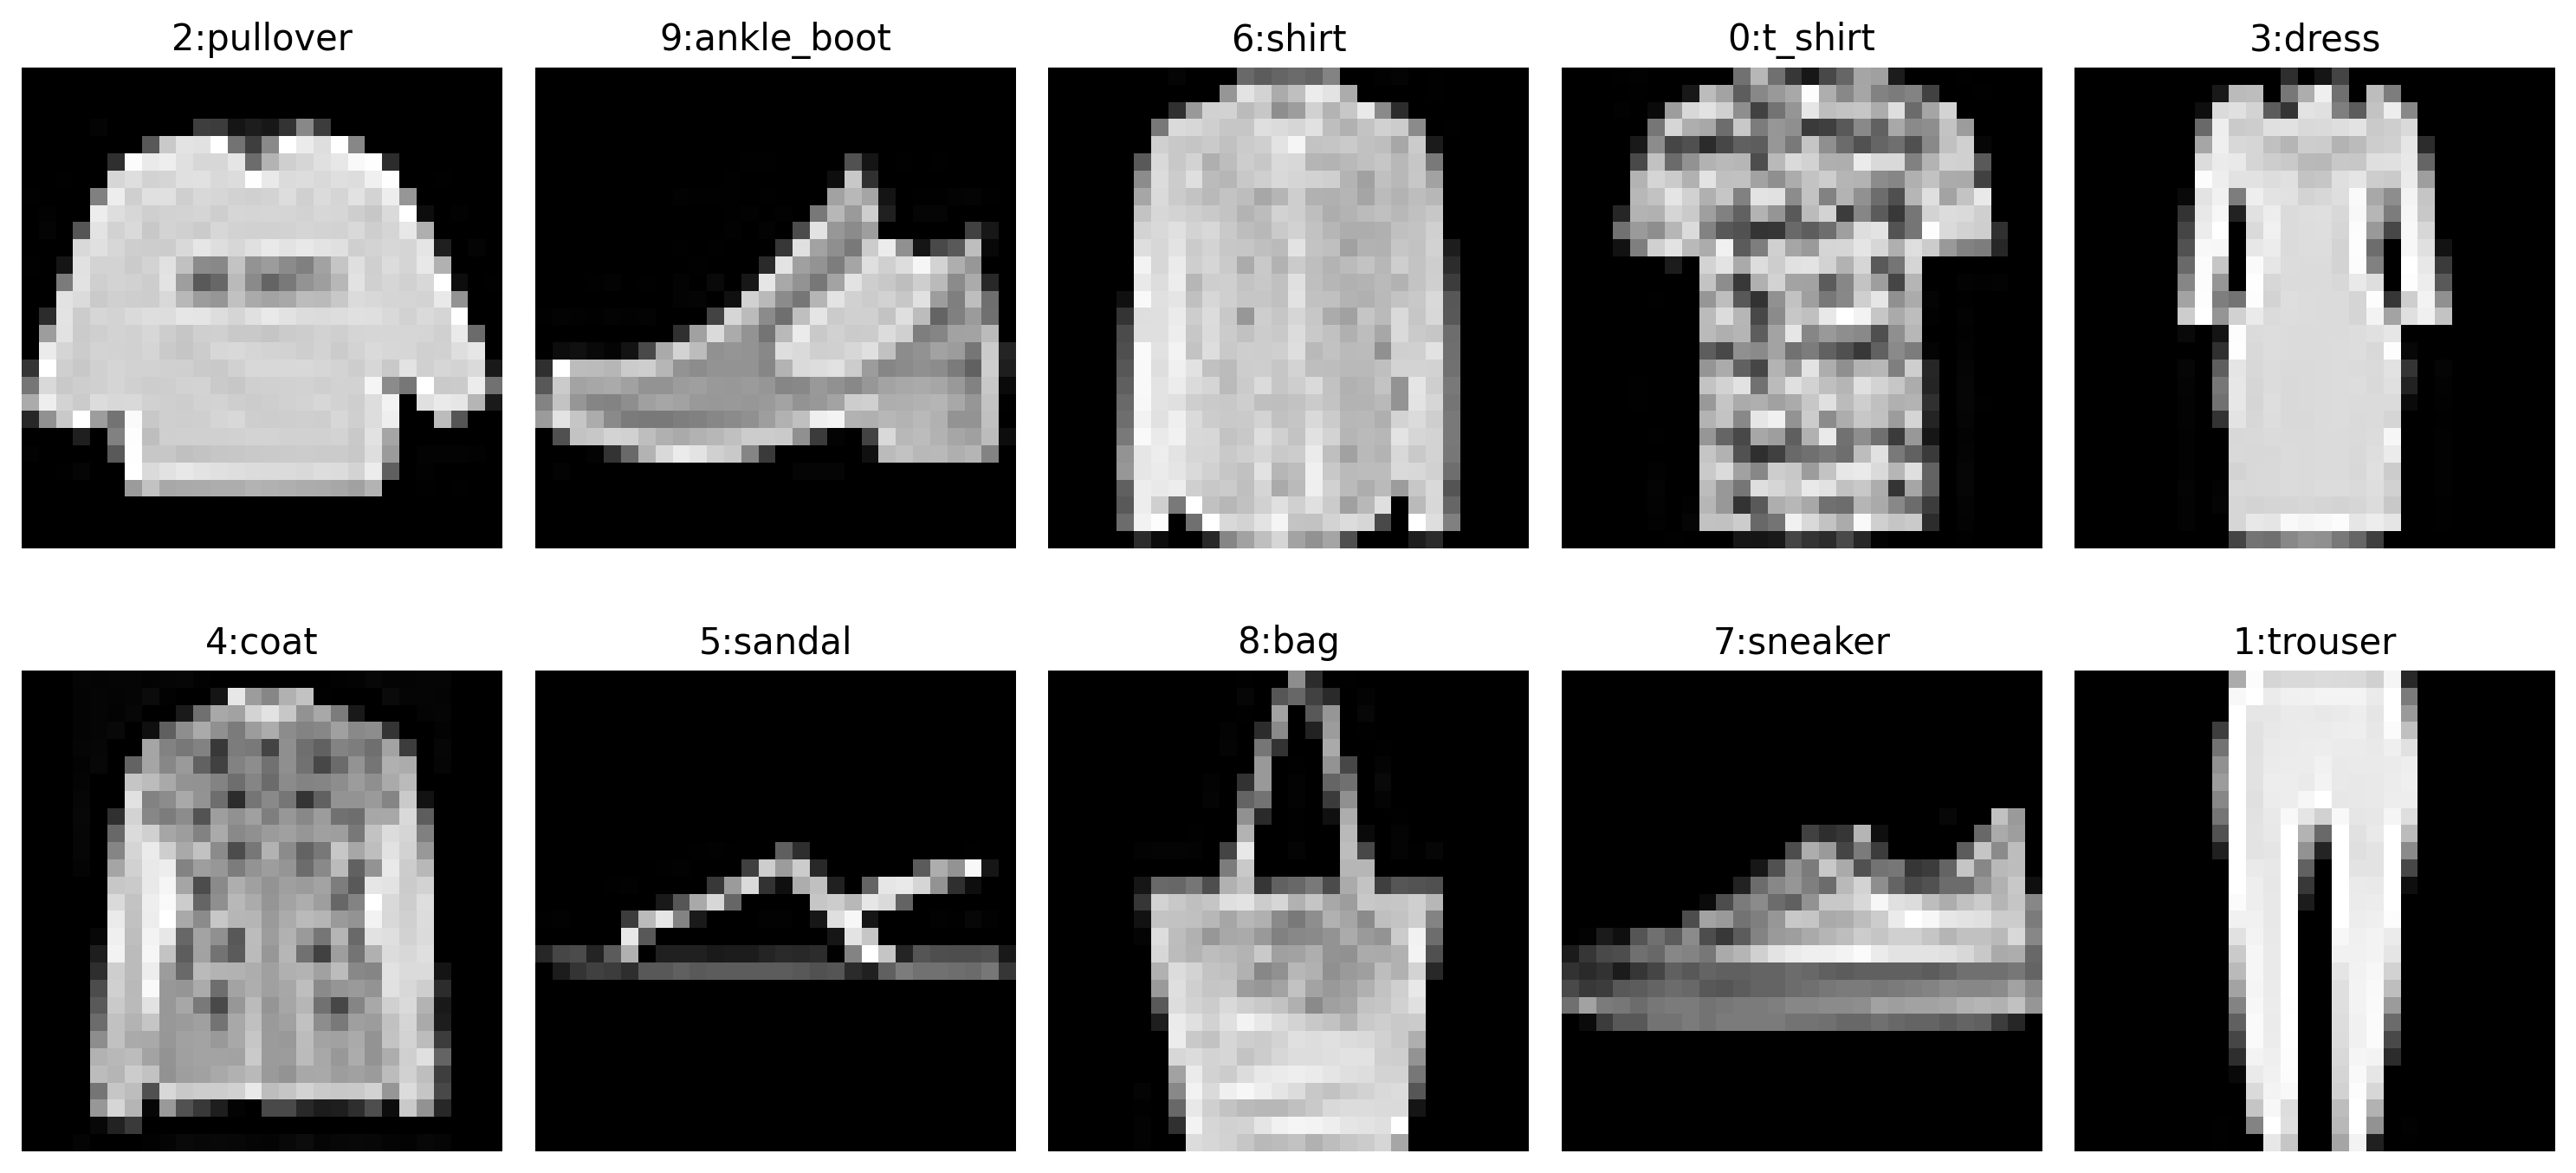

In [9]:
plt.figure(figsize=(12,6))
shown_labels = []
plot_index = 1
for i in range (len(xtrain)):
    label = ytrain[i]

    if label not in shown_labels:
        plt.subplot(2,5,plot_index)
        plt.imshow(xtrain[i].reshape(28,28),cmap='gray')
        plt.title(f"{label}:{label_names[label]}")
        plt.axis('off')
        shown_labels.append(label)
        plot_index+=1
    if len(shown_labels) == 10:
        break
plt.tight_layout()
plt.show()

In [10]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation = 'relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10,activation='softmax'))

In [11]:
model.compile(optimizer ='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [13]:
history = model.fit(xtrain,ytrain,epochs = 10,validation_split=0.2,batch_size = 32,callbacks=[early_stop],verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.7320 - loss: 0.7346 - val_accuracy: 0.8654 - val_loss: 0.3706
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8612 - loss: 0.3767 - val_accuracy: 0.8844 - val_loss: 0.3216
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8843 - loss: 0.3122 - val_accuracy: 0.8989 - val_loss: 0.2762
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.8995 - loss: 0.2757 - val_accuracy: 0.9036 - val_loss: 0.2738
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.9102 - loss: 0.2424 - val_accuracy: 0.9081 - val_loss: 0.2578
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.9161 - loss: 0.2272 - val_accuracy: 0.9114 - val_loss: 0.2529
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9208 - loss: 0.2091 - val_accuracy: 0.9116 - val_loss: 0.2522
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9294 -

In [14]:
train_loss,train_acc = model.evaluate(xtrain,ytrain)
test_loss,test_acc = model.evaluate(xtest,ytest)
print("Training Accuracy: ",train_acc)
print("Testing Accuracy: ",test_acc)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9498 - loss: 0.1355
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9120 - loss: 0.2399
Training Accuracy:  0.9420999884605408
Testing Accuracy:  0.9157000184059143


In [15]:
ypred = model.predict(xtest)
ypred_classes = np.argmax(ypred,axis=1) #argmax() returns:Index of maximum value
# axis=1 Means Find maximum across columnsfor each row/image.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [16]:
print(classification_report(ytest,ypred_classes,target_names=label_names))


              precision    recall  f1-score   support

     t_shirt       0.83      0.89      0.86      1000
     trouser       0.99      0.99      0.99      1000
    pullover       0.85      0.89      0.87      1000
       dress       0.91      0.93      0.92      1000
        coat       0.88      0.86      0.87      1000
      sandal       0.99      0.97      0.98      1000
       shirt       0.80      0.71      0.75      1000
     sneaker       0.94      0.97      0.96      1000
         bag       0.99      0.97      0.98      1000
  ankle_boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



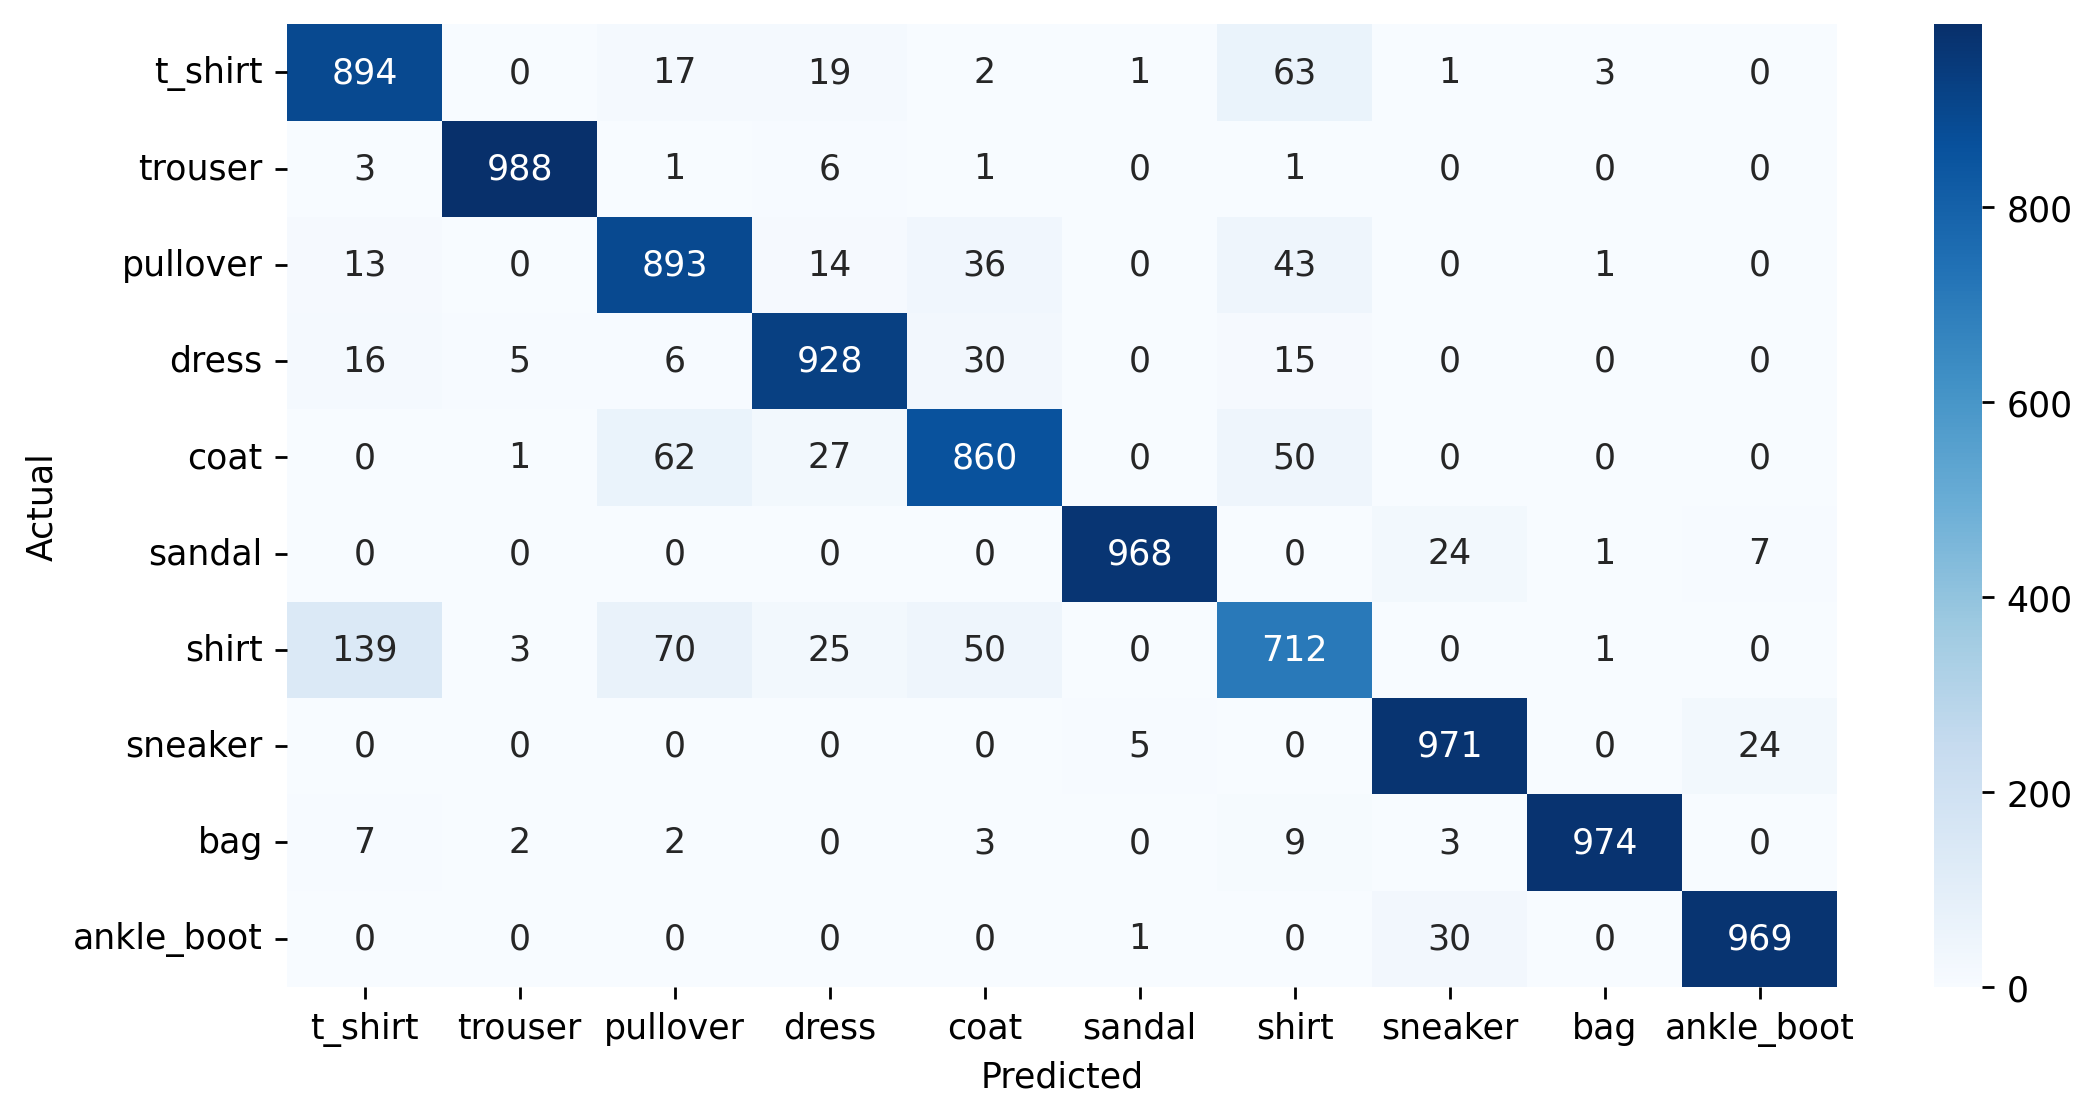

In [17]:
sns.heatmap(confusion_matrix(ytest,ypred_classes),annot=True,cmap='Blues',xticklabels=label_names,yticklabels=label_names,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

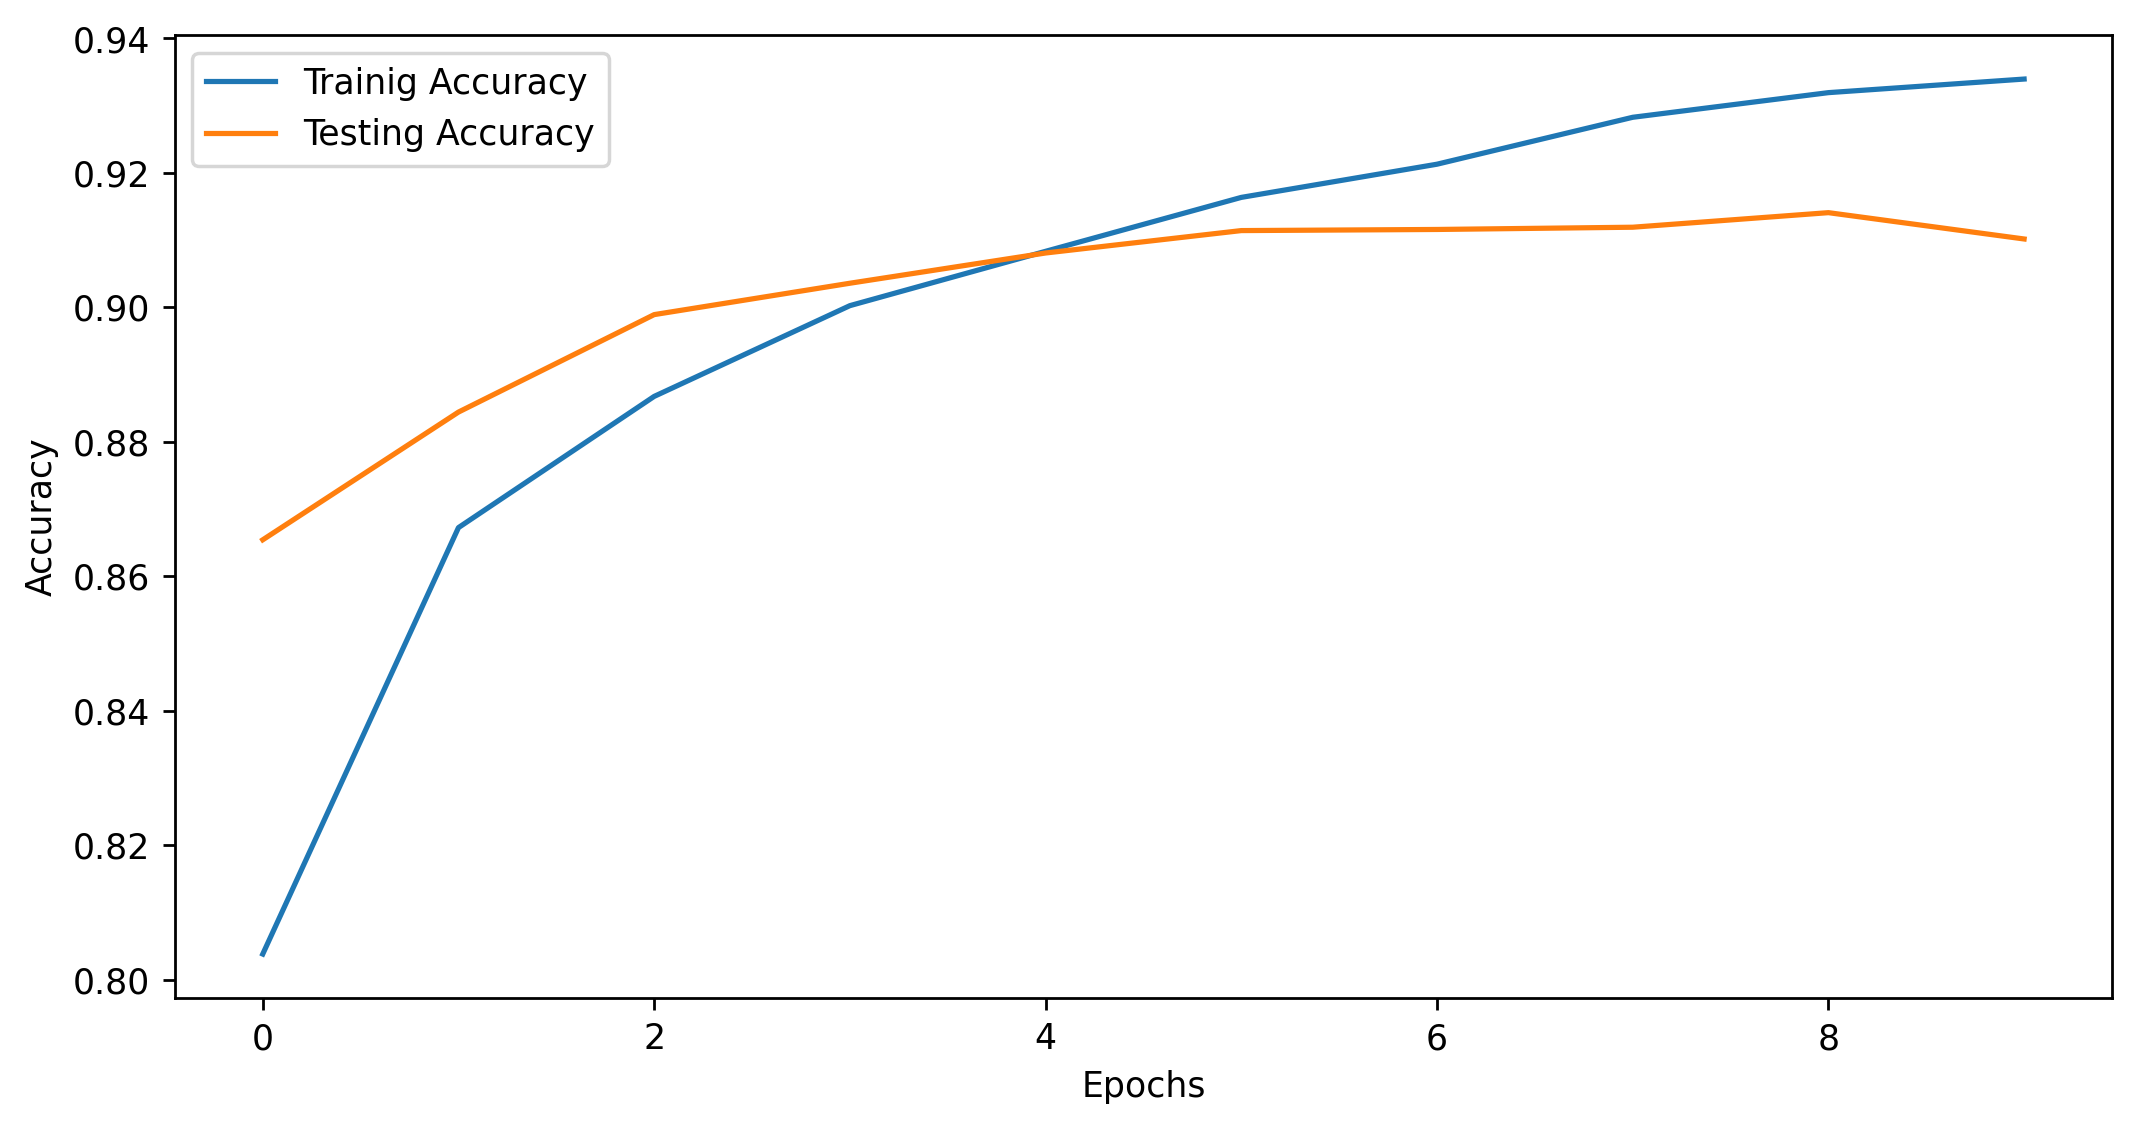

In [18]:
plt.plot(history.history['accuracy'],label= "Trainig Accuracy")
plt.plot(history.history['val_accuracy'],label="Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

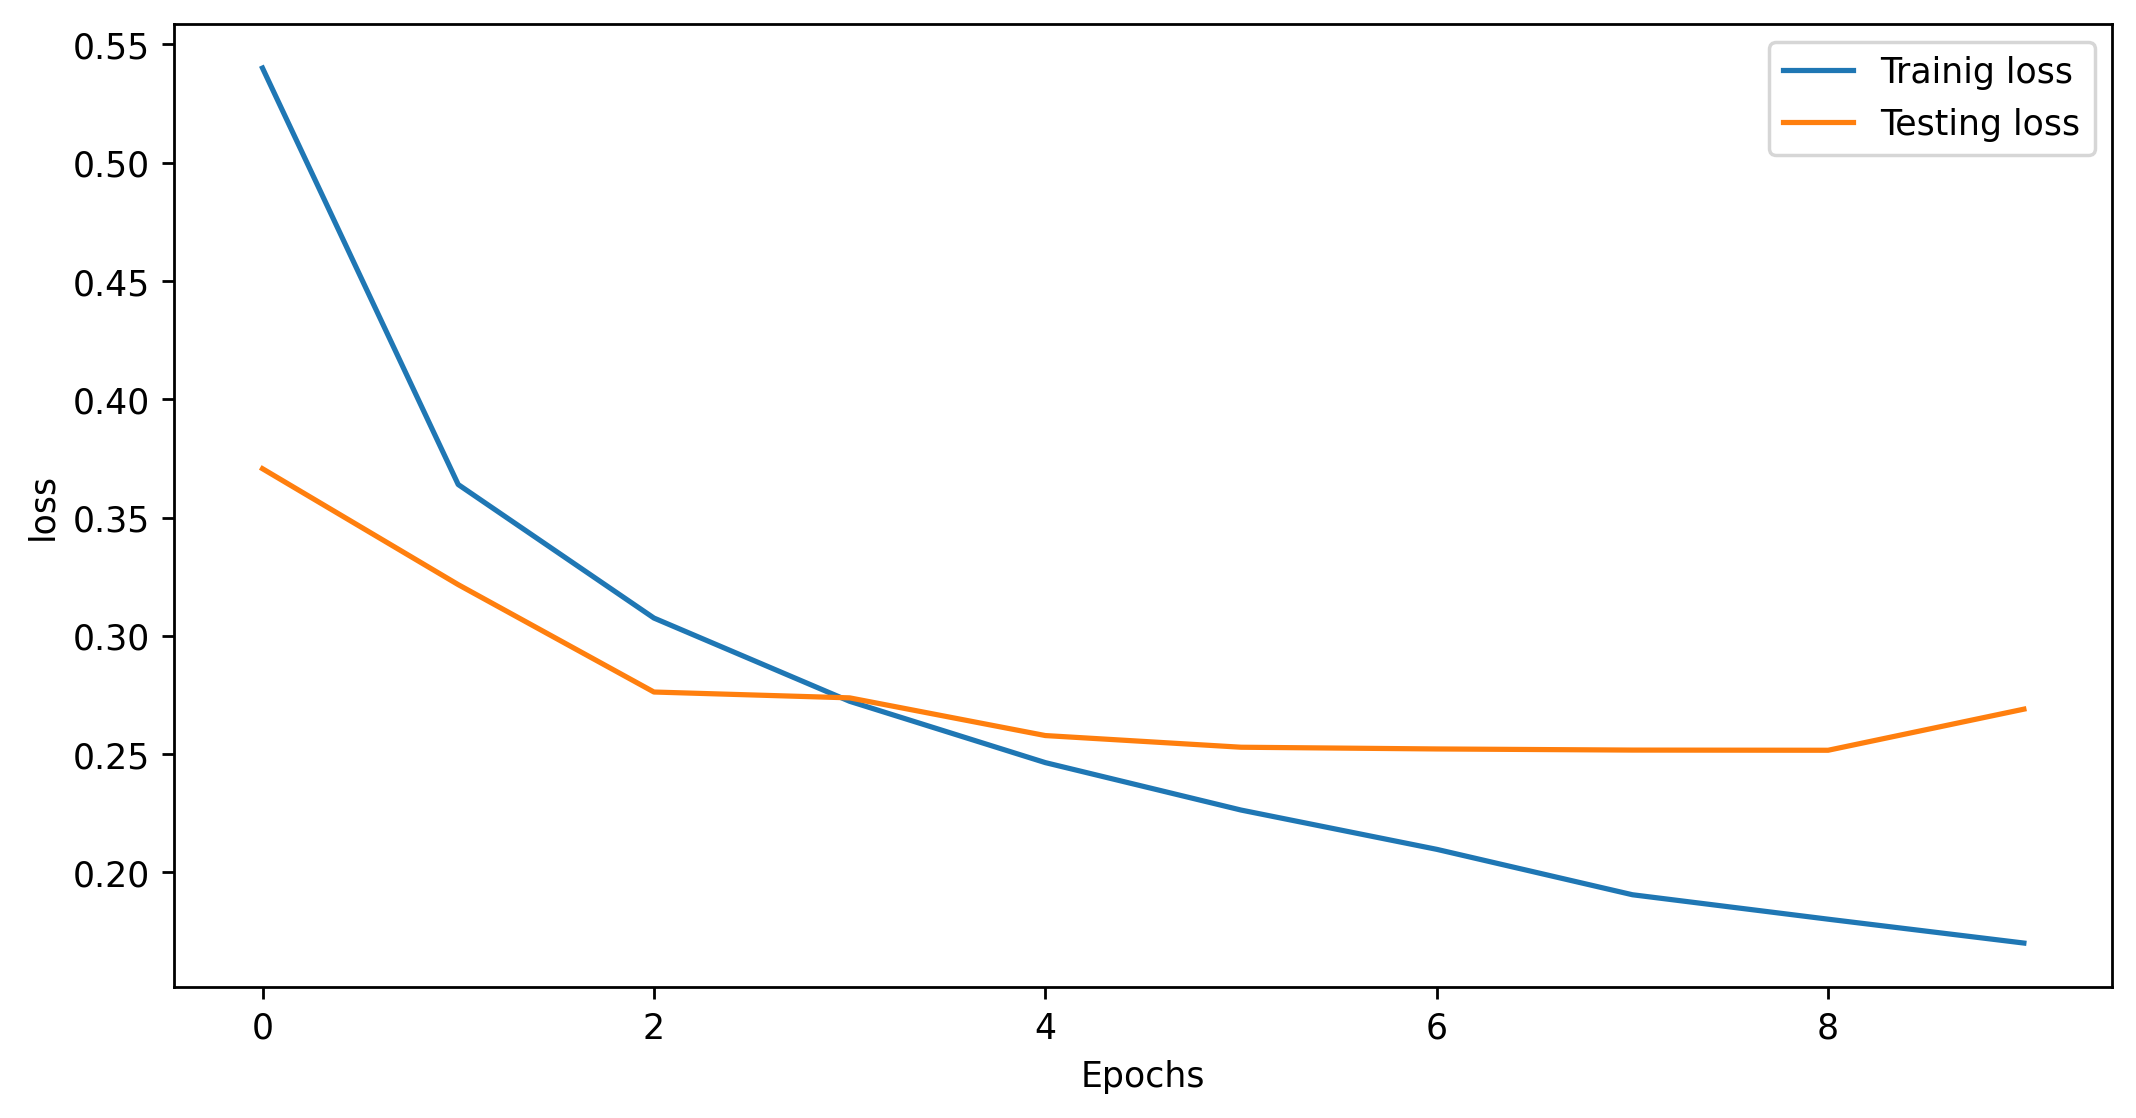

In [19]:
plt.plot(history.history['loss'],label= "Trainig loss")
plt.plot(history.history['val_loss'],label="Testing loss")
plt.xlabel("Epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [20]:
def prediction(index):
    prediction = model.predict(xtest[index:index+1])
    prediction_label = label_names[np.argmax(prediction)]
    actual_label = label_names[ytest[index]]
    print("Actual Label: " , actual_label)
    print("Predicted Label: ",prediction_label)
    plt.imshow(xtest[index].reshape(28,28),cmap='gray')
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Actual Label:  t_shirt
Predicted Label:  t_shirt


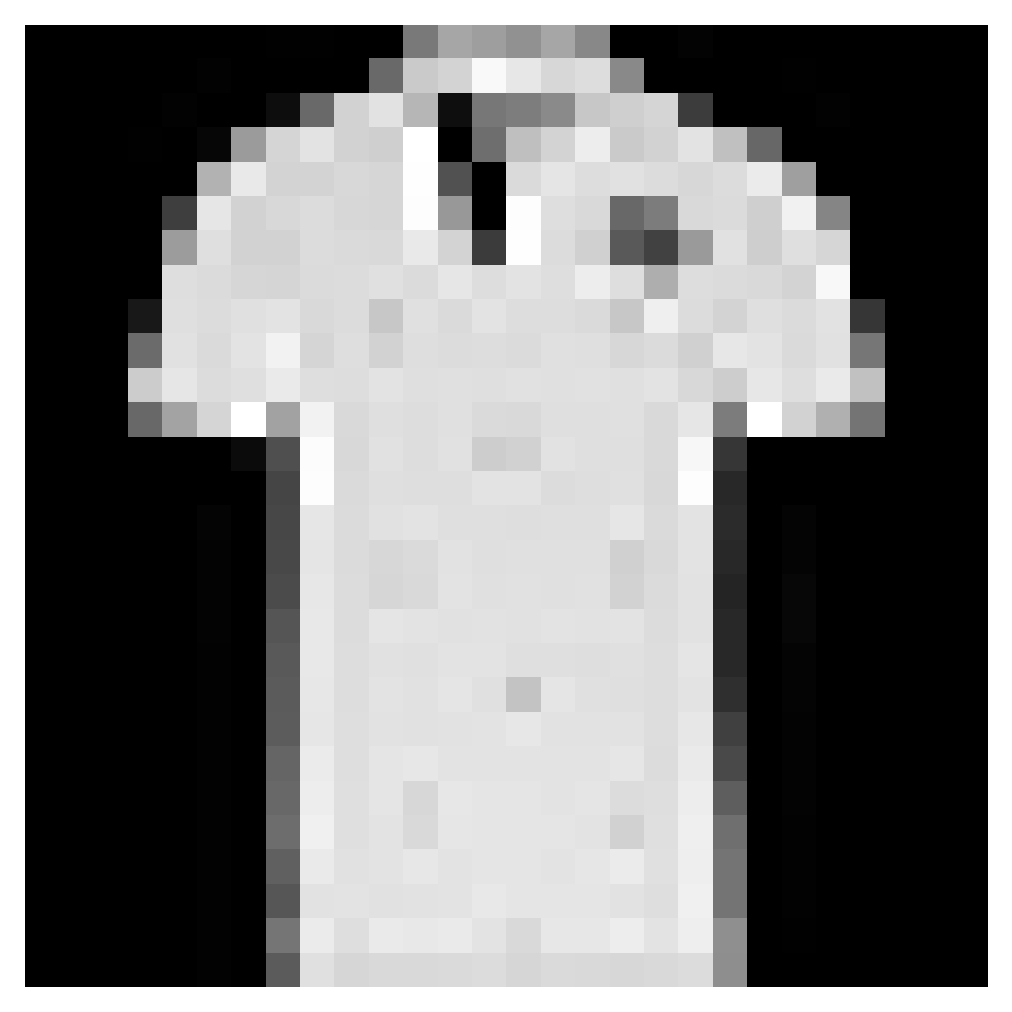

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Actual Label:  coat
Predicted Label:  coat


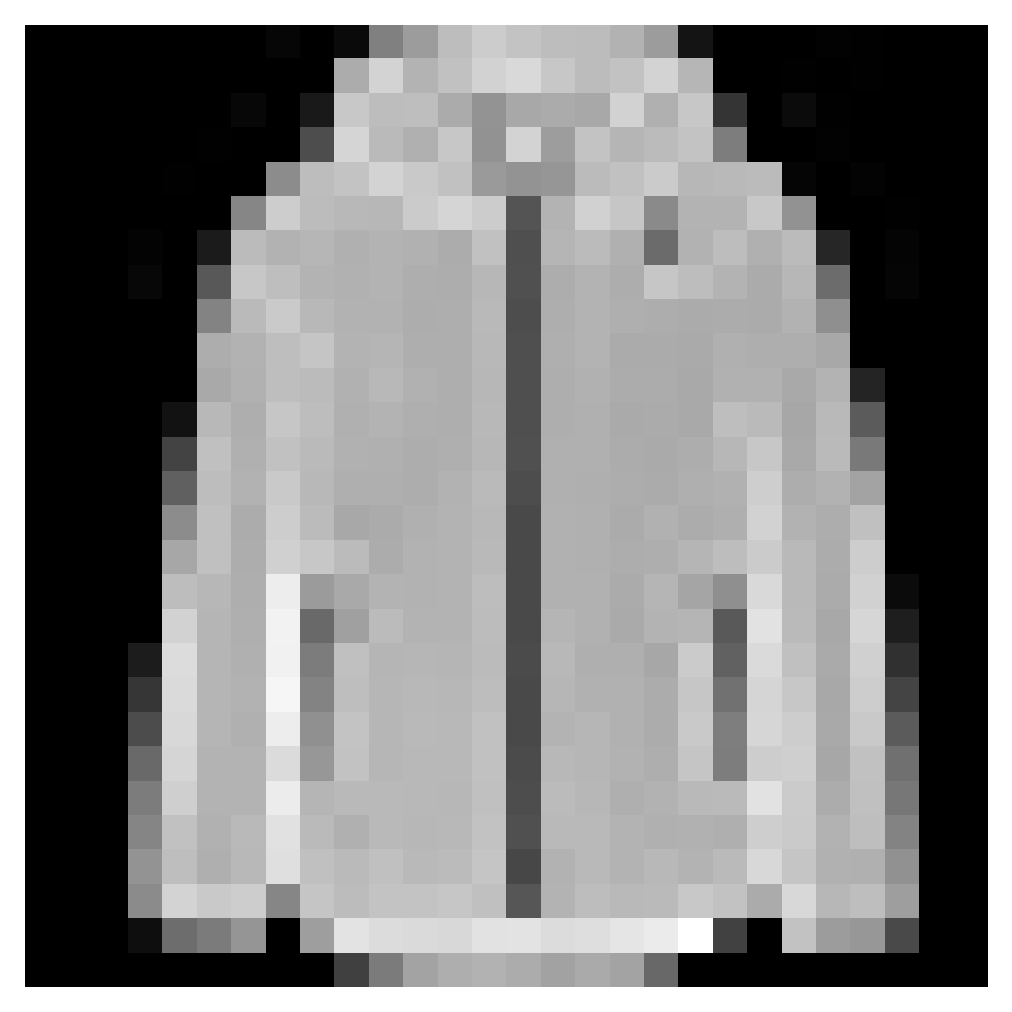

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Actual Label:  pullover
Predicted Label:  pullover


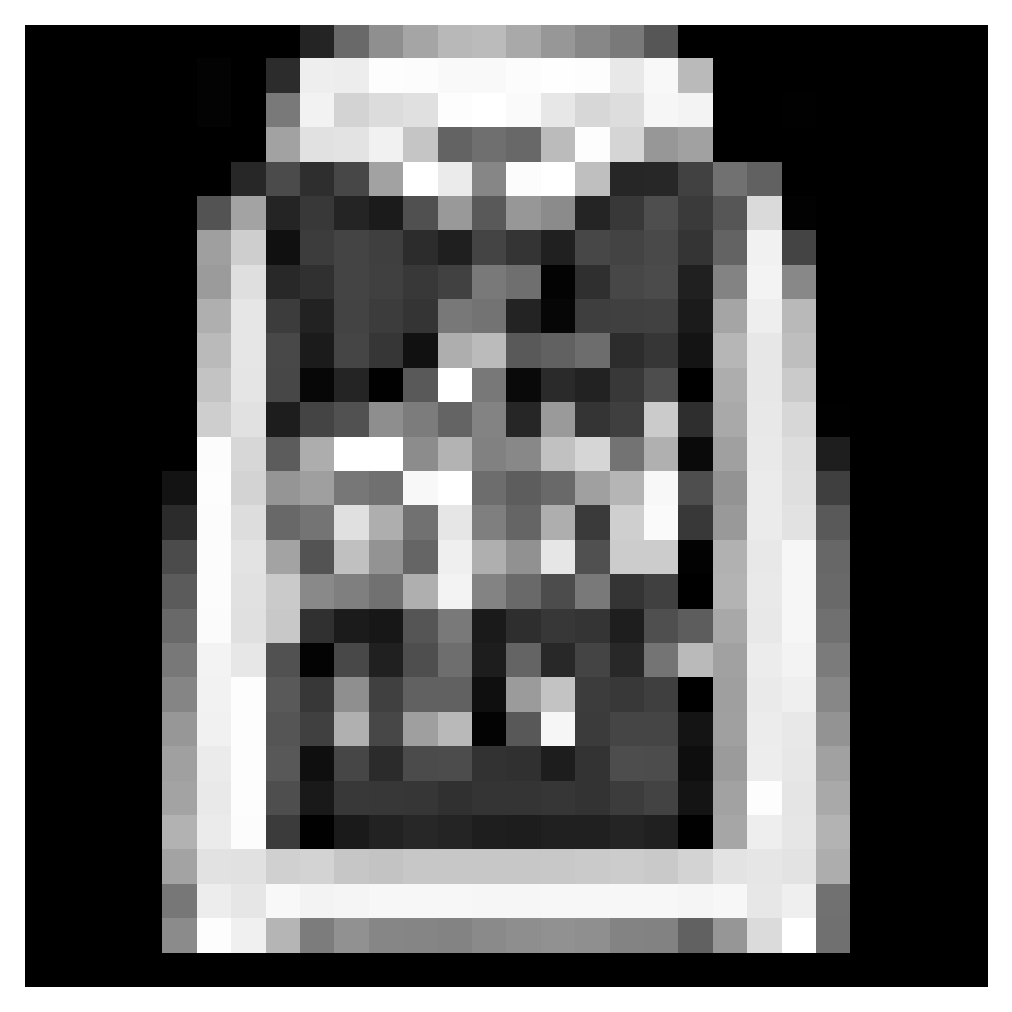

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Actual Label:  sandal
Predicted Label:  sandal


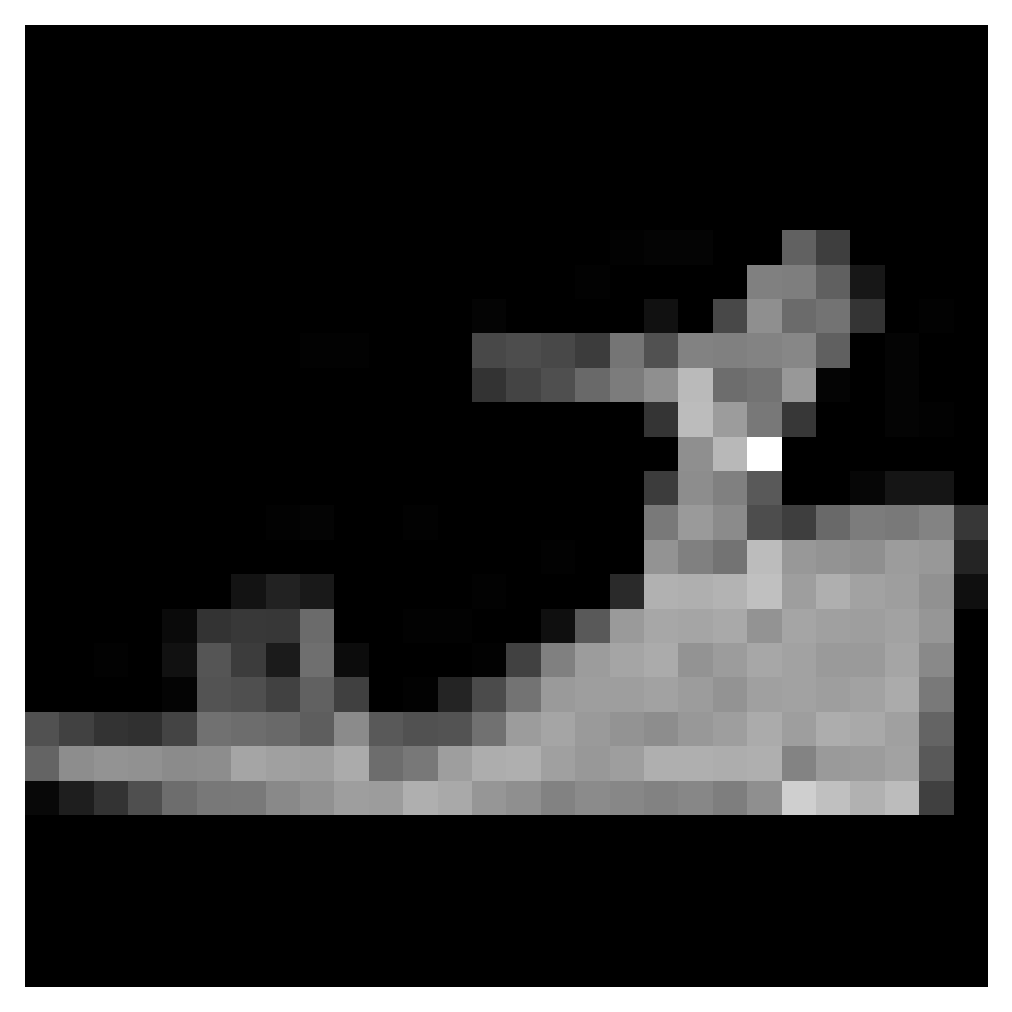

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Actual Label:  sandal
Predicted Label:  sandal


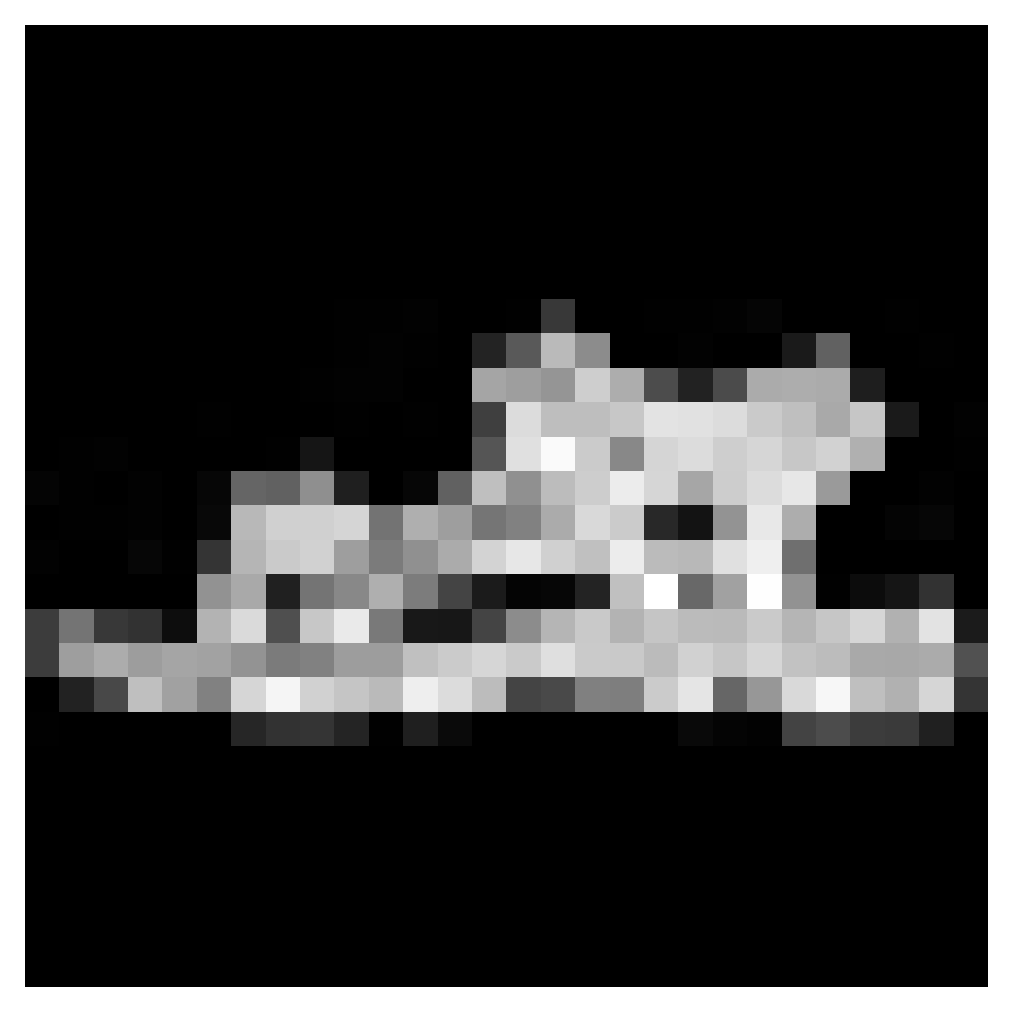

In [21]:
for i in range(200,205):
    prediction(i)